# 04 — Downstream READ localization

This phase evaluates **every successful notebook-02 concept row**: 155 raw $W_UJ$ rows and the independent 20-row MD subset. Each row chooses one source layer transparently by $|\sum_p WRITE_{l,p}\,READ_{l,p}|$, performs one single-source ablation/localization pass, flags the top 2 downstream MLPs and top 4 heads by absolute localization score, and computes activation-independent weight READ with 32 seeded random directions. Concept-level MLP READ is mean normalized MLP gain; attention READ is mean label-weighted normalized OV across the flagged components. These estimates are explicitly localization-selection-conditioned. The original four-cell raw-direction subset is retained for F4 without redundant localization passes. F6 compares raw/MD attribution READ with both weight READ families.

In [1]:
import json
import os
from pathlib import Path

ROOT = Path('/home/jovyan/j-space-thoughts')
os.chdir(ROOT)
os.environ['PIP_USER'] = 'false'
os.environ['PYTHONNOUSERSITE'] = '1'
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
metrics_path = ROOT / 'results/metrics.json'
twohop_path = ROOT / 'data/raw/02_twohop_qwen2.5-7b.json'
assert twohop_path.exists(), 'Notebook 02 raw payload is required'
print('Source payload MiB:', twohop_path.stat().st_size / 2**20)

Source payload MiB: 7.537077903747559


In [2]:
from src.localization_phase import CONCEPT_WEIGHT_READ_DEFINITION, NON_ADDITIVE_WARNING, run_qwen_localization_phase

localization = run_qwen_localization_phase(
    twohop_path=twohop_path,
    md_artifact_path=ROOT / 'data/directions/qwen2.5-7b_concept_vectors.pt',
    output_path=ROOT / 'data/raw/04_localization_qwen2.5-7b.json',
    figure_path=ROOT / 'results/figures/f4_read_localization_qwen2.5-7b.png',
    f6_figure_path=ROOT / 'results/figures/f6_direction_robustness_qwen2.5-7b.png',
    lower_quantile=0.25,
    upper_quantile=0.75,
    n_per_cell=1,
    n_source_layers=1,
    top_k_mlps=2,
    top_k_heads=4,
    n_random=32,
    n_bootstrap=5000,
    seed=1729,
)
assert localization['population_weight_read']['sample_counts']['n_by_method'] == {'jlens_raw_wu_j': 155, 'mean_difference': 20}
print('Population counts:', localization['population_weight_read']['sample_counts'])
print(NON_ADDITIVE_WARNING)

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

/opt/conda/lib/python3.11/site-packages/torch/autograd/graph.py:825: UserWarning: Flash Attention defaults to a non-deterministic algorithm. To explicitly enable determinism call torch.use_deterministic_algorithms(True, warn_only=False). (Triggered internally at ../aten/src/ATen/native/transformers/cuda/attention_backward.cu:102.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


WEIGHT READ 001/175 jlens_raw_wu_j animal-legs-buffalo2 source=L23
WEIGHT READ 002/175 jlens_raw_wu_j animal-nose-elephant source=L23


WEIGHT READ 003/175 jlens_raw_wu_j basketball-players source=L25


WEIGHT READ 004/175 jlens_raw_wu_j beverage-source-wine source=L11
WEIGHT READ 005/175 jlens_raw_wu_j chem-organic-Z source=L17


...

WEIGHT READ 172/175 mean_difference ex2-language-capital-Greek source=L20
WEIGHT READ 173/175 mean_difference ex2-language-capital-Hungarian source=L17


WEIGHT READ 174/175 mean_difference ex2-language-capital-Polish source=L19


WEIGHT READ 175/175 mean_difference ex2-language-capital-Swedish source=L15


LOCALIZATION COMPUTED: F4 items=4, population=175 ({'jlens_raw_wu_j': 155, 'mean_difference': 20})
Clean-gradient dot (single-source-ablated minus clean) component scores are overlapping first-order mediation/localization diagnostics. Attention and MLP paths, and earlier and later components, overlap; scores must not be summed or interpreted as an additive causal decomposition.


Population counts: {'n_total': 175, 'n_by_method': {'jlens_raw_wu_j': 155, 'mean_difference': 20}}
Clean-gradient dot (single-source-ablated minus clean) component scores are overlapping first-order mediation/localization diagnostics. Attention and MLP paths, and earlier and later components, overlap; scores must not be summed or interpreted as an additive causal decomposition.


## Curated metrics versus raw audit trail

The complete 175-row per-position component scores and every seeded weight-null draw remain in `data/raw/04_localization_qwen2.5-7b.json`. The versioned metrics file retains the original four F4 localization records plus one compact summary per population row: method-specific direction provenance, selected source, notebook-02 WRITE/attribution READ/real all-band ablation damage, flagged component IDs, concept-level MLP and attention weight READ, bootstrap partial correlations, and standardized regressions. Raw null arrays and full population localization tensors stay out of `metrics.json`.

In [3]:
from src.metrics import save_json

component_keys = ('component', 'layer', 'head', 'score', 'abs_score', 'delta_norm', 'clean_gradient_norm', 'clean_activation_norm', 'perturbed_activation_norm', 'capture')
weight_keys = ('component', 'layer', 'head', 'score', 'abs_score', 'attribution_abs_rank', 'gain', 'normalized_gain', 'random_median', 'gain_random_percentile', 'ov_norm', 'normalized_ov_norm', 'random_median_ov_norm', 'ov_norm_random_percentile', 'label_cosine', 'label_cosine_random_percentile', 'label_weighted_normalized_ov', 'n_random', 'seed', 'weight_metric')
def keep(row, keys):
    return {key: row[key] for key in keys if key in row}

slim_records = []
for record in localization['localizations']:
    loc = record['localization']
    slim_records.append({
        key: record[key] for key in ('name', 'source', 'category', 'intermediate', 'concept_token_id', 'concept_token_surface', 'target_token_id', 'foil_token_id', 'direction_method', 'direction_formula', 'source_layer', 'source_selection_rank', 'source_selection', 'sampling_cell', 'notebook02_summary')
    } | {
        'localization': {
            key: loc[key] for key in ('source_layer', 'component_layers', 'intervention', 'behavior_metric', 'clean_metric', 'perturbed_metric', 'actual_delta', 'positive_damage', 'localization_estimator')
        } | {
            'mlps': [keep(row, component_keys) for row in loc['mlps']],
            'attention_heads': [keep(row, component_keys) for row in loc['attention_heads']],
        },
        'weight_read': {
            'metadata': record['weight_read']['metadata'],
            'mlps': [keep(row, weight_keys) for row in record['weight_read']['mlps']],
            'attention_heads': [keep(row, weight_keys) for row in record['weight_read']['attention_heads']],
        },
    })
population = localization['population_weight_read']
population_rows = [{
    key: record[key] for key in ('name', 'source', 'category', 'intermediate', 'concept_token_id', 'concept_token_surface', 'target_token_id', 'foil_token_id', 'direction_method', 'direction_convention', 'direction_source', 'source_layer', 'source_selection', 'notebook02_summary', 'concept_weight_read')
} for record in population['records']]
population_curated = {key: population[key] for key in ('status', 'definition', 'sample_counts', 'source_layer_selection', 'md_artifact', 'analysis', 'raw_nulls_retained')}
population_curated['records'] = population_rows
curated = {key: localization[key] for key in ('schema_version', 'status', 'metadata', 'selection', 'source_layer_selection', 'sample_counts', 'f4_candidates', 'attribution_weight_rank_agreement', 'figures', 'interpretation_guardrail')}
curated['localizations'] = slim_records
curated['population_weight_read'] = population_curated
metrics = json.loads(metrics_path.read_text())
metrics.setdefault('localization', {})['qwen2.5-7b-instruct'] = curated
save_json(metrics_path, metrics)
print('Curated localization merged; metrics size MiB:', metrics_path.stat().st_size / 2**20)

Curated localization merged; metrics size MiB: 42.54319477081299


In [4]:
import pandas as pd

display(pd.DataFrame([{
    'item': row['name'],
    'cell': row['sampling_cell'],
    'source_layer': row['source_layer'],
    'WRITE': row['notebook02_summary']['write_strength'],
    'READ': row['notebook02_summary']['read_strength'],
    'single_source_damage': row['localization']['positive_damage'],
} for row in localization['localizations']]))
agreement = localization['attribution_weight_rank_agreement']
display(pd.DataFrame([
    {'comparison': key, 'status': value['status'], 'n': value['n'], 'spearman_rho': value.get('spearman_rho')}
    for key, value in agreement.items() if isinstance(value, dict) and 'status' in value
]))
print('F4 candidates:', localization['f4_candidates'])
population = localization['population_weight_read']
population_table = pd.DataFrame([{
    'item': row['name'],
    'method': row['direction_method'],
    'source_layer': row['source_layer'],
    'WRITE': row['notebook02_summary']['write_strength'],
    'attribution_READ': row['notebook02_summary']['attribution_read_strength'],
    'MLP_weight_READ': row['concept_weight_read']['mlp']['estimate'],
    'attention_weight_READ': row['concept_weight_read']['attention']['estimate'],
    'all_band_damage': row['notebook02_summary']['all_band_ablation_positive_damage'],
} for row in population['records']])
display(population_table.groupby('method')[['WRITE', 'attribution_READ', 'MLP_weight_READ', 'attention_weight_READ', 'all_band_damage']].agg(['count', 'mean', 'median']))
conditional_rows = []
for method, method_result in population['analysis']['by_method'].items():
    for family, family_result in method_result['weight_families'].items():
        read_partial = family_result['partial_correlations']['causal_weight_read_given_write']
        write_partial = family_result['partial_correlations']['causal_write_given_weight_read']
        regression = family_result['standardized_regression']
        conditional_rows.append({
            'method': method, 'weight_family': family, 'N': family_result['n'],
            'partial_CAUSAL_weightREAD_given_WRITE': read_partial.get('estimate'),
            'partial_READ_ci_low': read_partial.get('ci_low'), 'partial_READ_ci_high': read_partial.get('ci_high'),
            'partial_CAUSAL_WRITE_given_weightREAD': write_partial.get('estimate'),
            'partial_WRITE_ci_low': write_partial.get('ci_low'), 'partial_WRITE_ci_high': write_partial.get('ci_high'),
            'beta_WRITE': regression.get('coefficients', {}).get('write'),
            'beta_weight_READ': regression.get('coefficients', {}).get('read'),
        })
display(pd.DataFrame(conditional_rows))
print(CONCEPT_WEIGHT_READ_DEFINITION['selection_conditioning_warning'])

,item,cell,source_layer,WRITE,READ,single_source_damage
0,us-detroit-state-capital,high_write_high_read,22,36.434732,0.061943,5.500
1,ex2-language-capital-Hungarian,high_write_low_read,25,29.746318,0.011633,1.250
2,us-san-jose-state-capital,low_write_high_read,22,19.049158,0.070780,8.375
3,func-pumps-chambers,low_write_low_read,23,9.802717,0.005779,0.250


,comparison,status,n,spearman_rho
0,mlp_attribution_vs_normalized_gain,ESTIMATED,8,-0.619048
1,head_attribution_vs_normalized_ov,ESTIMATED,16,0.850000
2,head_attribution_vs_label_weighted_ov,ESTIMATED,16,0.723529


F4 candidates: {'driver_candidate': {'name': 'us-san-jose-state-capital', 'selection_cell': 'low_write_high_read', 'write_strength': 19.049158369004726, 'read_strength': 0.07077994362969346, 'all_band_ablation_positive_damage': 8.9375, 'selection_rule': 'largest measured all-band ablation damage within the sampled high-READ strata; attribution READ and name break ties'}, 'low_read_candidate': {'name': 'ex2-language-capital-Hungarian', 'selection_cell': 'high_write_low_read', 'write_strength': 29.746318355557463, 'read_strength': 0.011633041425444563, 'all_band_ablation_positive_damage': 1.0625, 'selection_rule': 'lowest attribution READ, preferring the high-WRITE/low-READ cell; WRITE and name break ties'}, 'guardrail': 'These are visualization candidates selected after notebook-02 measurements. The low-READ candidate is not declared narration, and the driver label is not an independently validated class assignment.'}


WRITE                       attribution_READ            \
                count       mean     median            count      mean   
method                                                                   
jlens_raw_wu_j    155  23.860475  23.588599              155  0.022710   
mean_difference    20  83.257519  84.200109               20  0.007367   

                          MLP_weight_READ                     \
                   median           count      mean   median   
method                                                         
jlens_raw_wu_j   0.019216             155  2.165227  2.11074   
mean_difference  0.006991              20  0.973836  0.91168   

                attention_weight_READ                     all_band_damage  \
                                count      mean    median           count   
method                                                                      
jlens_raw_wu_j                    155  0.518186  0.325190             155   
mean_difference                    20  0.075016  0.072534              20   

                                    
                     mean   median  
method                              
jlens_raw_wu_j   3.098727  3.12500  
mean_difference  1.301562  1.84375

,method,weight_family,N,partial_CAUSAL_weightREAD_given_WRITE,partial_READ_ci_low,partial_READ_ci_high,partial_CAUSAL_WRITE_given_weightREAD,partial_WRITE_ci_low,partial_WRITE_ci_high,beta_WRITE,beta_weight_READ
0,jlens_raw_wu_j,mlp,155,-0.304497,-0.425517,-0.169243,-0.089721,-0.225558,0.046514,-0.086700,-0.307668
1,jlens_raw_wu_j,attention,155,0.013895,-0.138648,0.197241,-0.040760,-0.194006,0.109531,-0.040759,0.013885
2,mean_difference,mlp,20,0.035209,-0.467335,0.526940,-0.431564,-0.749617,0.046111,-0.433099,0.031894
3,mean_difference,attention,20,-0.472246,-0.719729,-0.186390,-0.479217,-0.744386,-0.047461,-0.432940,-0.424817


Weight READ is evaluated only after components are selected by absolute activation-localization score; it is not an unbiased scan of all weights.


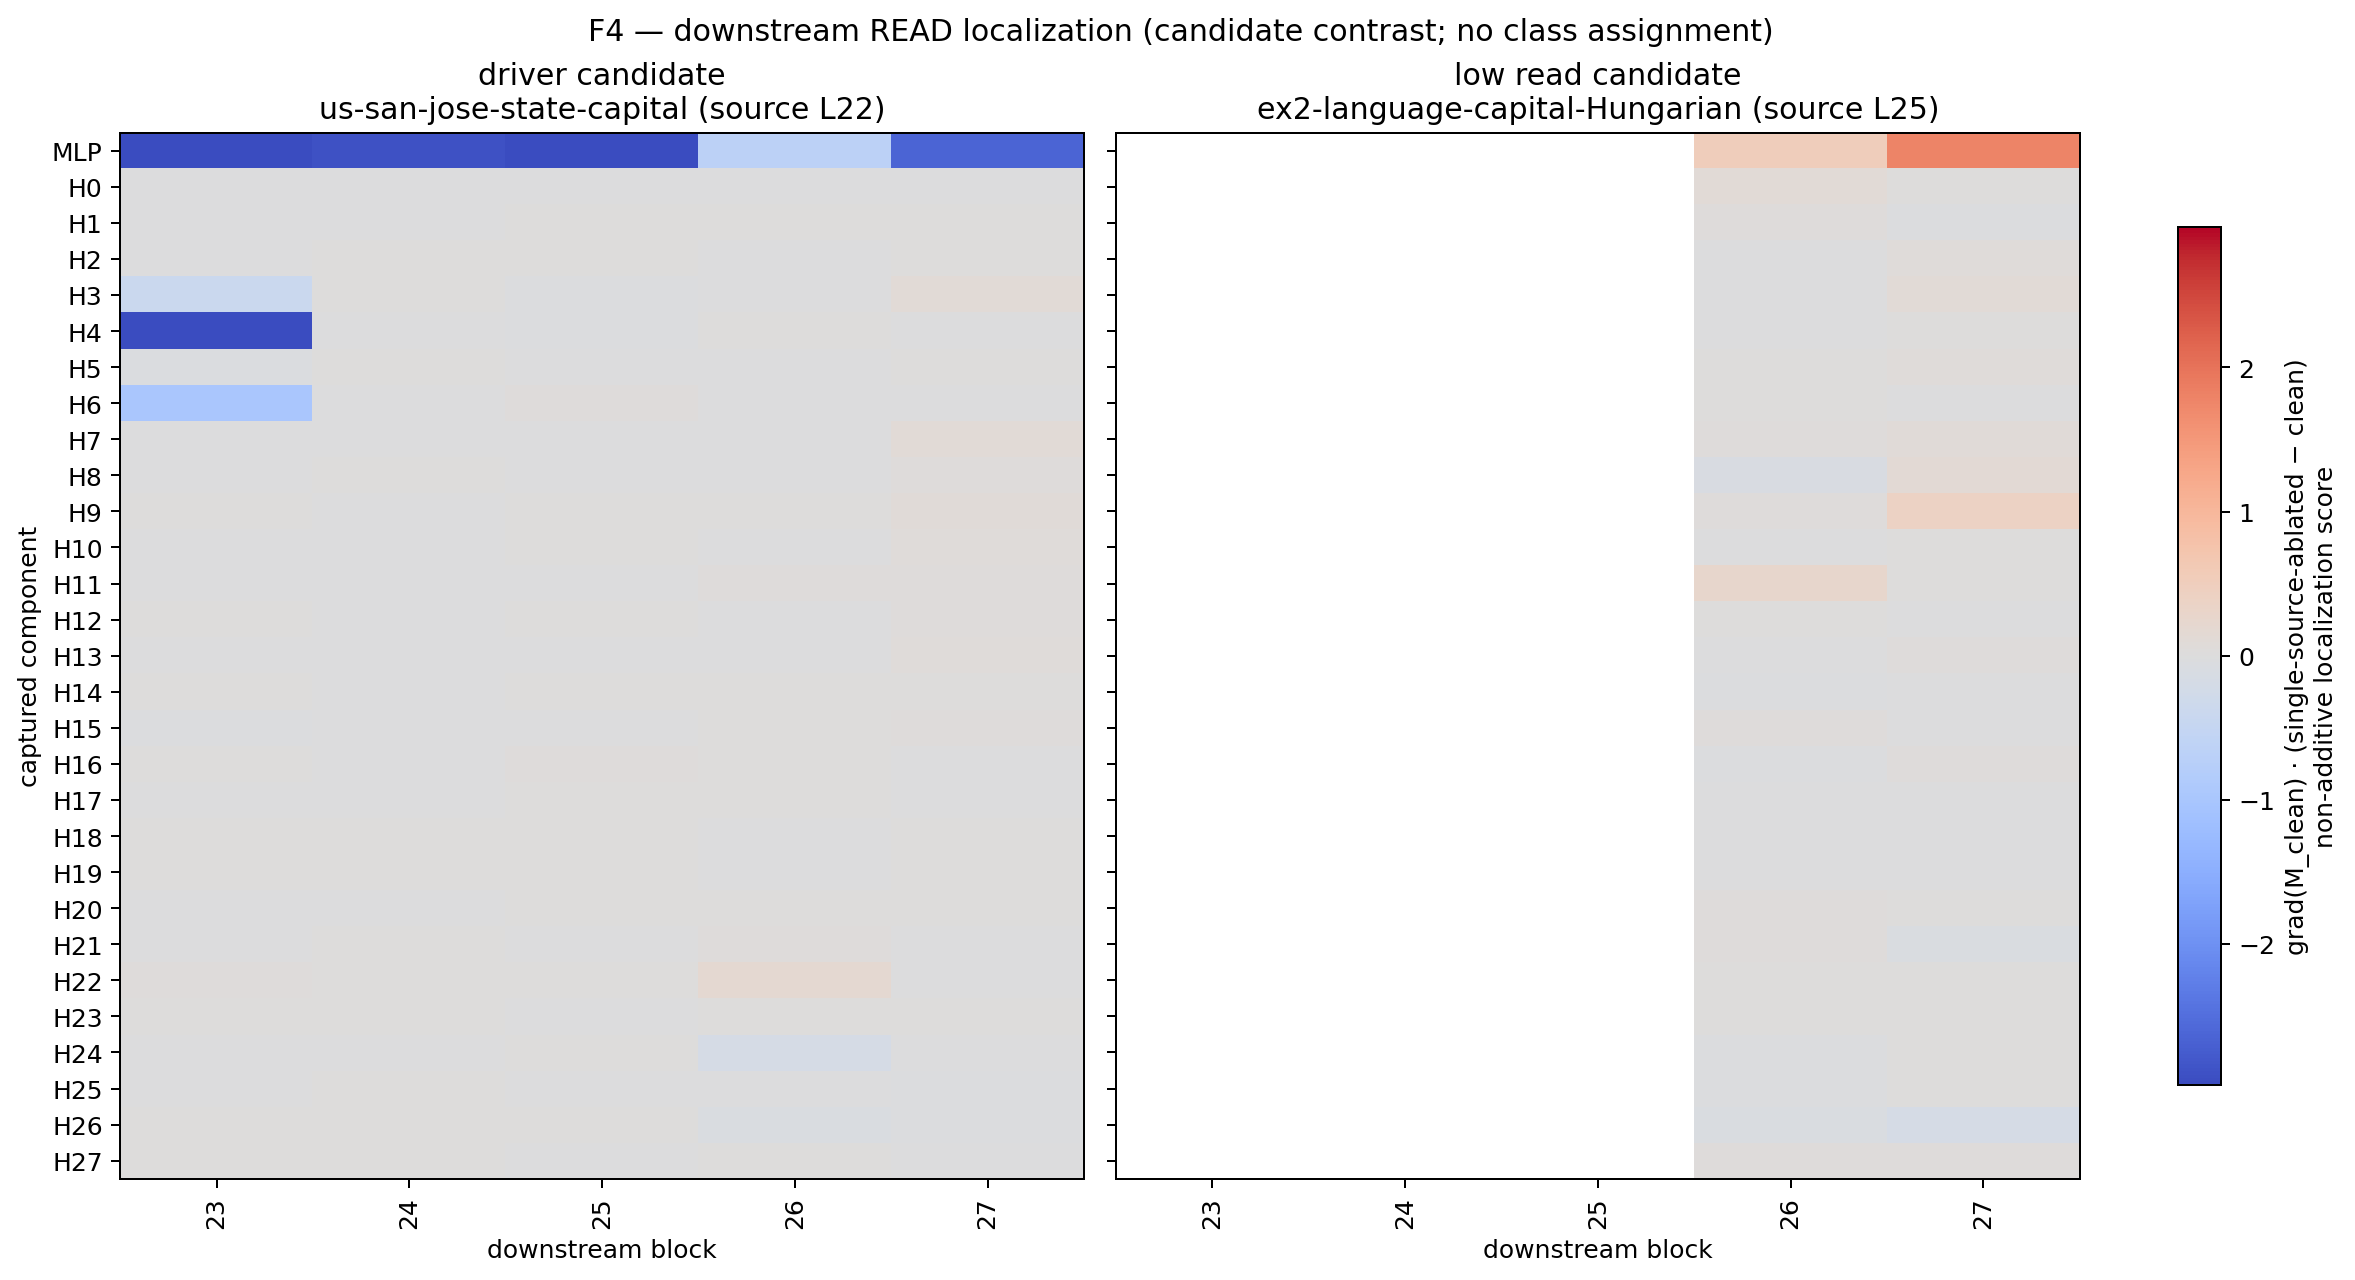

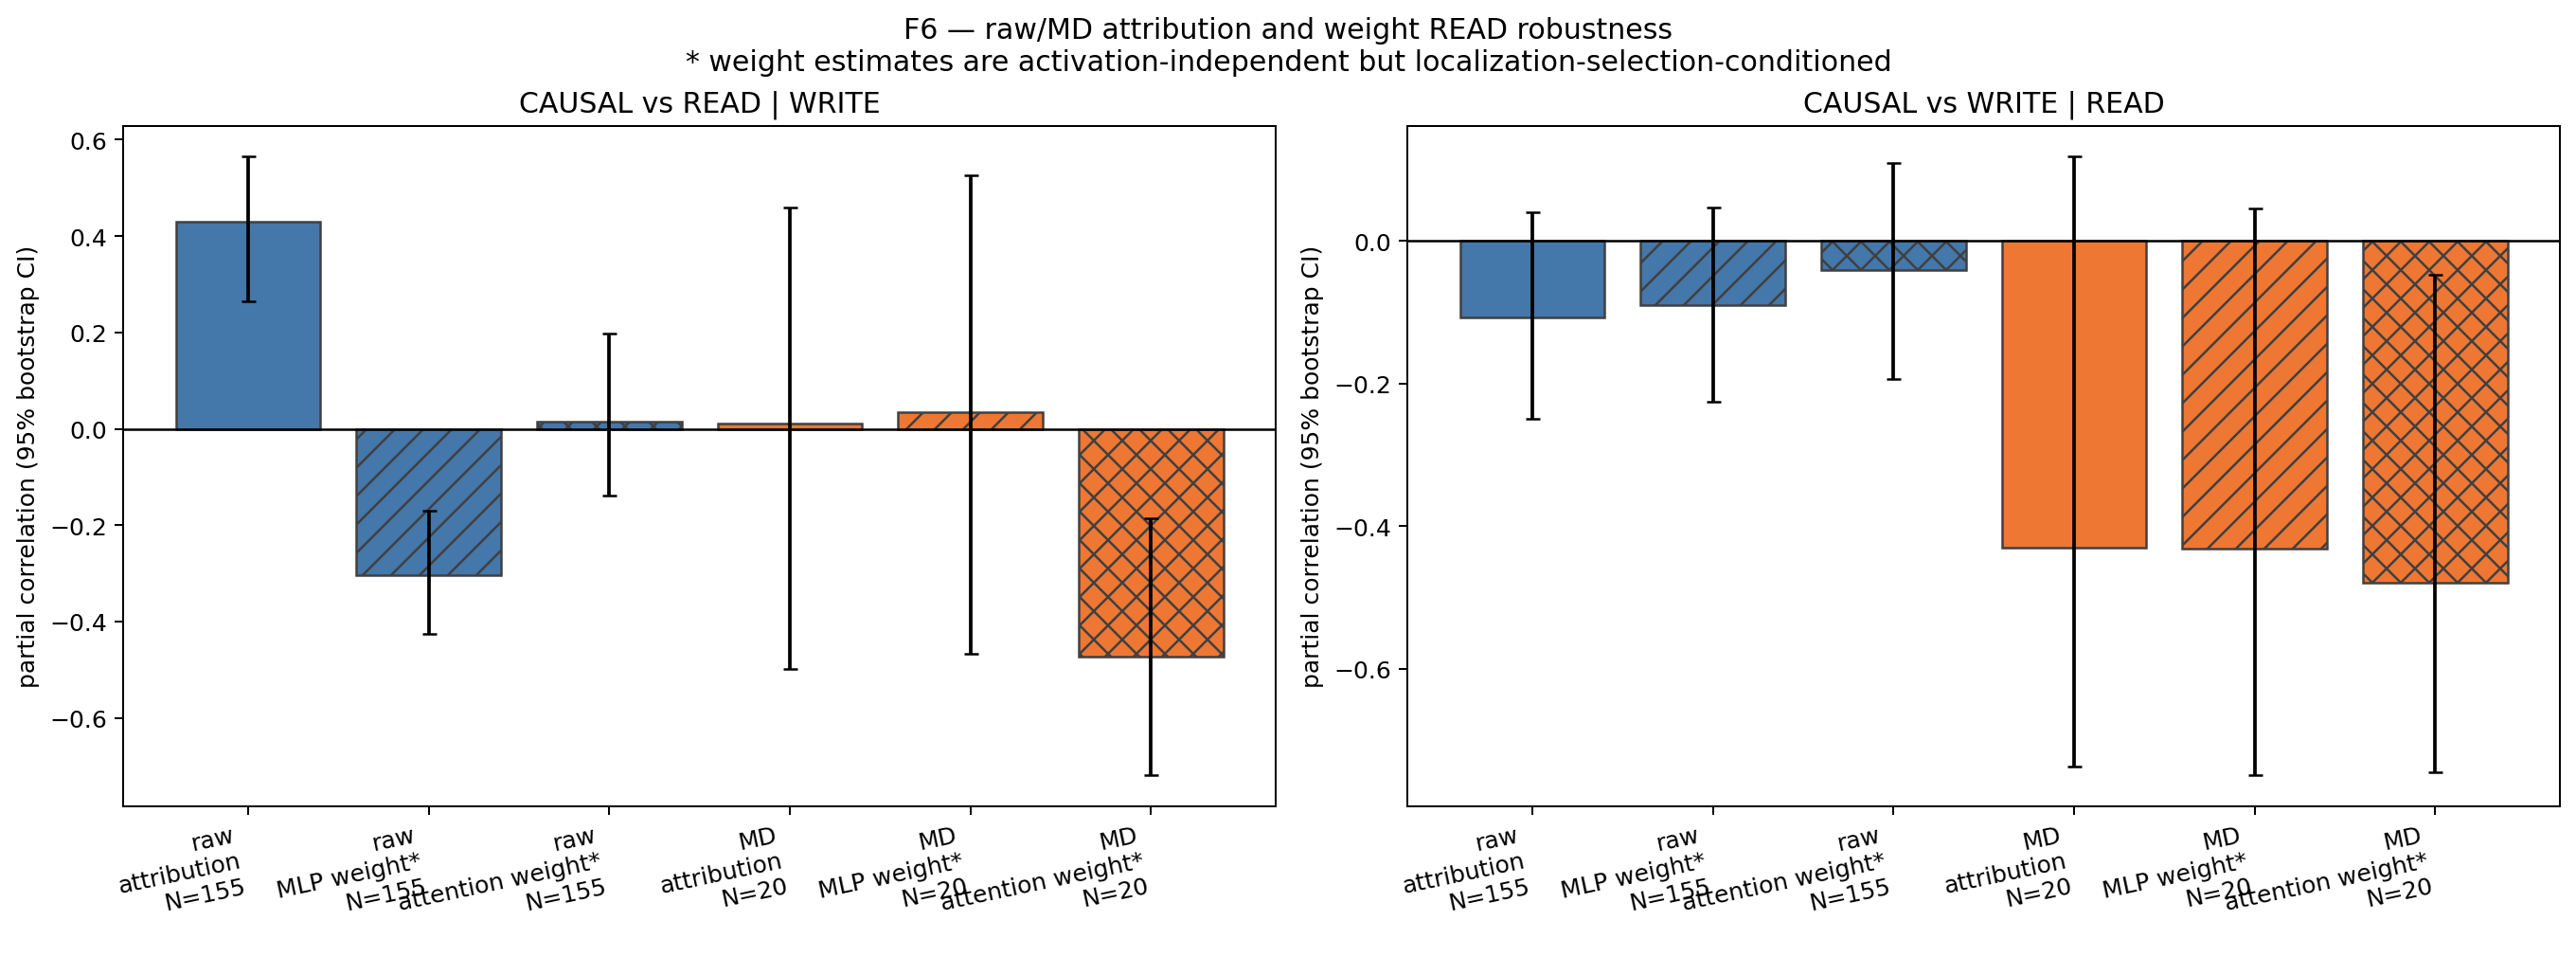

In [5]:
from IPython.display import Image, display

display(Image(filename=localization['figures']['f4']))
display(Image(filename=localization['figures']['f6']))

In [6]:
print('PHASE 04 COMPUTED — FOUR-ITEM F4 + FULL WEIGHT-READ POPULATION')
print('Selected strict quartile cells:', localization['selection']['provenance']['cells'])
print('Population counts:', localization['population_weight_read']['sample_counts'])
print('F6:', localization['figures']['f6'])
print('Weight estimates are activation-independent but localization-selection-conditioned; component scores are not additive mediation estimates.')

PHASE 04 COMPUTED — FOUR-ITEM F4 + FULL WEIGHT-READ POPULATION
Selected strict quartile cells: {'high_write_high_read': {'n_strict_candidates': 12, 'n_selected': 1, 'n_fallback': 0}, 'high_write_low_read': {'n_strict_candidates': 8, 'n_selected': 1, 'n_fallback': 0}, 'low_write_high_read': {'n_strict_candidates': 8, 'n_selected': 1, 'n_fallback': 0}, 'low_write_low_read': {'n_strict_candidates': 12, 'n_selected': 1, 'n_fallback': 0}}
Population counts: {'n_total': 175, 'n_by_method': {'jlens_raw_wu_j': 155, 'mean_difference': 20}}
F6: results/figures/f6_direction_robustness_qwen2.5-7b.png
Weight estimates are activation-independent but localization-selection-conditioned; component scores are not additive mediation estimates.
